In [1]:
from astropy.table import Table, unique, hstack, vstack, join
from astropy.coordinates import SkyCoord, match_coordinates_sky, Distance
from astropy.cosmology import Planck18, FlatLambdaCDM
from astropy.io import fits
import astropy.units as u
import astropy.constants as const
import pandas as pd

from tqdm import tqdm

import numpy as np

from scipy.optimize import curve_fit

import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from hyperfit.linfit import LinFit
import corner
import sys
sys.path.insert(1, '/global/u1/s/sgmoore1/DESI_SGA/TF/')
from help_functions import profile_histogram

# Read in catalog

In [2]:
## Read in full SGA catalog
SGA = Table.read('/global/cfs/cdirs/cosmo/data/sga/2020/SGA-2020.fits', 'ELLIPSE')

## Read in rotation curve parameters
curves= Table.read('/pscratch/sd/n/nravi/BTFR/Elliptical_sphdisk_refitspirals_BPT_illustris_v11.fits')

## Read in SGA_IDs for each of the MaNGA objects
manga_crossmatch= Table.read('/global/homes/s/sgmoore1/DESI_SGA/MaNGA/MaNGA_SGA_crossmatch_2022-06-28.txt', format='ascii.commented_header')

## Combine to get SGA_IDs for each rotation curve
manga_curves = join(curves, manga_crossmatch['SGA_ID', 'plateifu'], keys=['plateifu'])

## Combine rotation curves with SGA
SGA_manga = join(SGA, manga_curves, keys='SGA_ID')
len(SGA_manga)

8422

In [3]:
## Apply quality cuts to rotation curves

SGA_manga = SGA_manga[(SGA_manga['alpha']<=99) & (SGA_manga['v_max_err']/SGA_manga['v_max']<=2) 
    & (SGA_manga['v_max']<1000) & (SGA_manga['v_max']>10) & (SGA_manga['R_MAG_SB26']>0)]
len(SGA_manga)

4687

In [4]:
## Compute total surface brightness within 26th isophote
SGA_manga['SB'] = SGA_manga['R_MAG_SB26'] + 2.5*np.log10(np.pi*SGA_manga['SMA_SB26']**2*SGA_manga['BA'])
# SGA_manga['SB'] = SGA_manga['R_MAG_SB26'] + 2.5*np.log10(np.pi*SGA_manga['SMA_SB26']**2)

### Compute physical radius for R26 in kpc/h
Planck18_h = FlatLambdaCDM(H0=100, Om0=0.3151)
dist = Distance(z=np.abs(SGA_manga['z']), cosmology=Planck18_h)
SGA_manga['R26_kpc'] = dist.to('kpc')*np.tan(0.5*SGA_manga['D26']*u.arcmin)

In [5]:
#### How many are "dwarves"
np.sum(SGA_manga['R_MAG_SB26'] > 17)

46

Text(0.5, 0, 'Integrated Surface Brightness within R26')

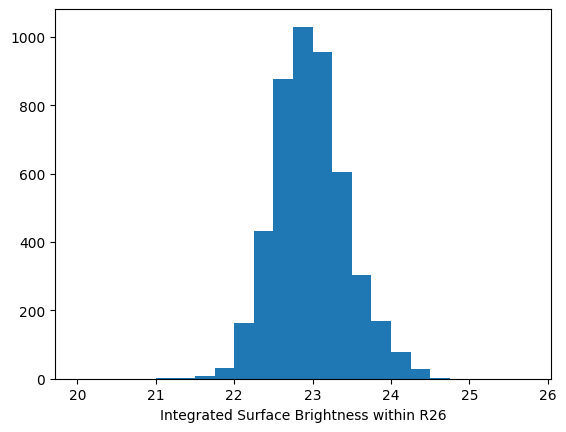

In [6]:
plt.figure()
plt.hist(SGA_manga['SB'], bins=np.arange(20,26,0.25))
plt.xlabel('Integrated Surface Brightness within R26')

# Look at SGA vs. MaNGA parameters

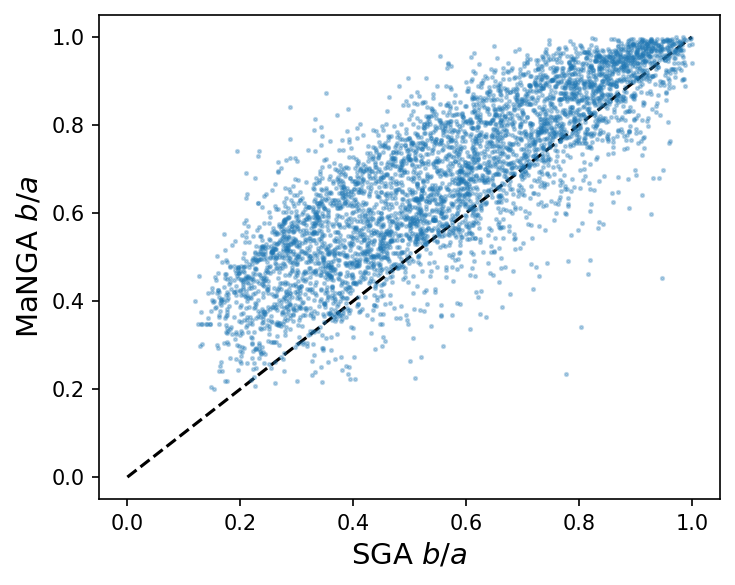

In [7]:
plt.figure(figsize=(5,4), tight_layout=True, facecolor='none', dpi=150)

plt.errorbar(SGA_manga['BA'], SGA_manga['ba'], alpha=0.3, fmt='.', ms=3)

plt.plot((0,1), (0,1), 'k--')

plt.xlabel(r'SGA $b/a$', fontsize=14)
plt.ylabel(r'MaNGA $b/a$', fontsize=14)

plt.show();

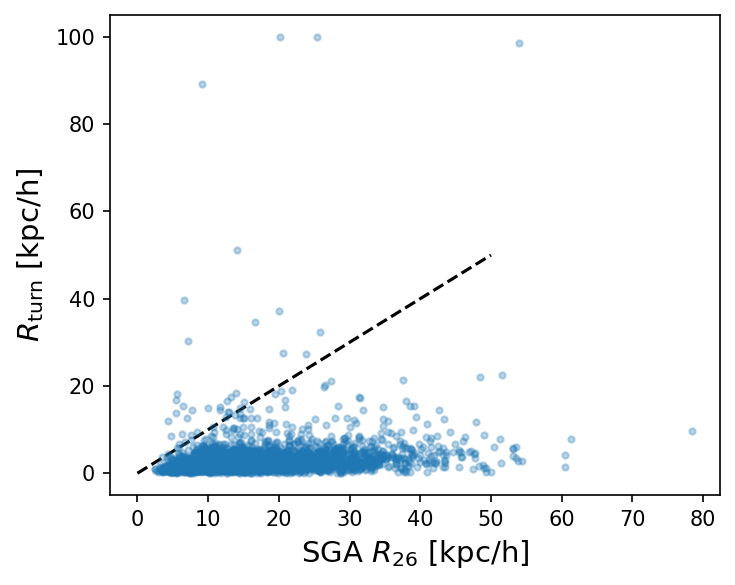

In [8]:
sbins = np.arange(16,22, 0.5)
ds = 0.5*np.diff(sbins)
sc = 0.5*(sbins[1:] + sbins[:-1])

plt.figure(figsize=(5,4), tight_layout=True, facecolor='none', dpi=150)

plt.errorbar(SGA_manga['R26_kpc'], SGA_manga['r_turn'], alpha=0.3, fmt='.')

plt.plot((0,50), (0,50), 'k--')

plt.xlabel(r'SGA $R_{26}$ [kpc/h]', fontsize=14)
plt.ylabel(r'$R_{\text{turn}}$ [kpc/h]', fontsize=14)

# plt.ylim(0,10)

plt.show();

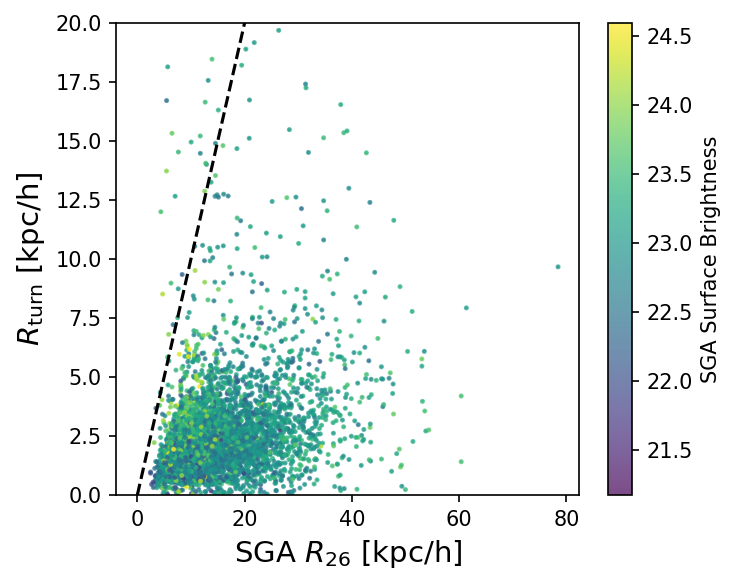

In [9]:
sbins = np.arange(16,22, 0.5)
ds = 0.5*np.diff(sbins)
sc = 0.5*(sbins[1:] + sbins[:-1])

plt.figure(figsize=(5,4), tight_layout=True, facecolor='none', dpi=150)

plt.scatter(SGA_manga['R26_kpc'], SGA_manga['r_turn'], c=SGA_manga['SB'], alpha=0.7, s=2)

plt.plot((0,50), (0,50), 'k--')

plt.xlabel(r'SGA $R_{26}$ [kpc/h]', fontsize=14)
plt.ylabel(r'$R_{\text{turn}}$ [kpc/h]', fontsize=14)
plt.colorbar(label='SGA Surface Brightness')
plt.ylim(0,20)

plt.show();

# Plot some rotation curves

In [10]:
def v_Vmax(Rturn, alpha, r):
    v = r /((Rturn**alpha + r**alpha)**(1/alpha))
    return v

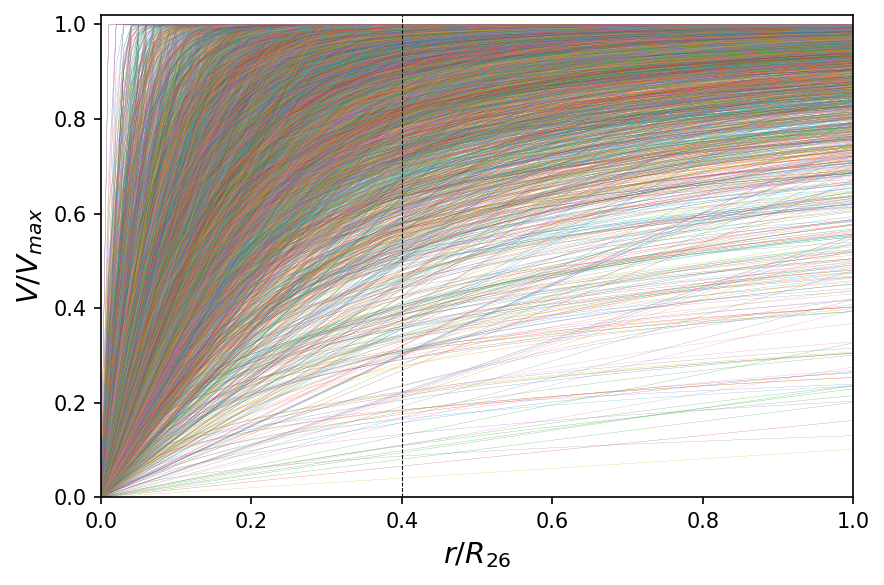

In [11]:
r = np.linspace(0,1,100)

plt.figure(figsize=(6,4), tight_layout=True, facecolor='none', dpi=150)

for i in range(0,len(SGA_manga)):
    vel = v_Vmax((SGA_manga['r_turn'][i]/SGA_manga['R26_kpc'][i]), SGA_manga['alpha'][i], r)
    plt.plot(r, vel, lw=0.1)

plt.axvline(x=0.4, color='k', lw=0.5, ls='dashed')
# plt.plot([17,22], A*np.array([17,22]) + (B + v_median), 'k')

plt.xlabel(r'$r/R_{26}$', fontsize=14)
plt.ylabel(r'$V/V_{max}$', fontsize=14)
plt.xlim(0,1)
plt.ylim(0,1.02)
plt.show();

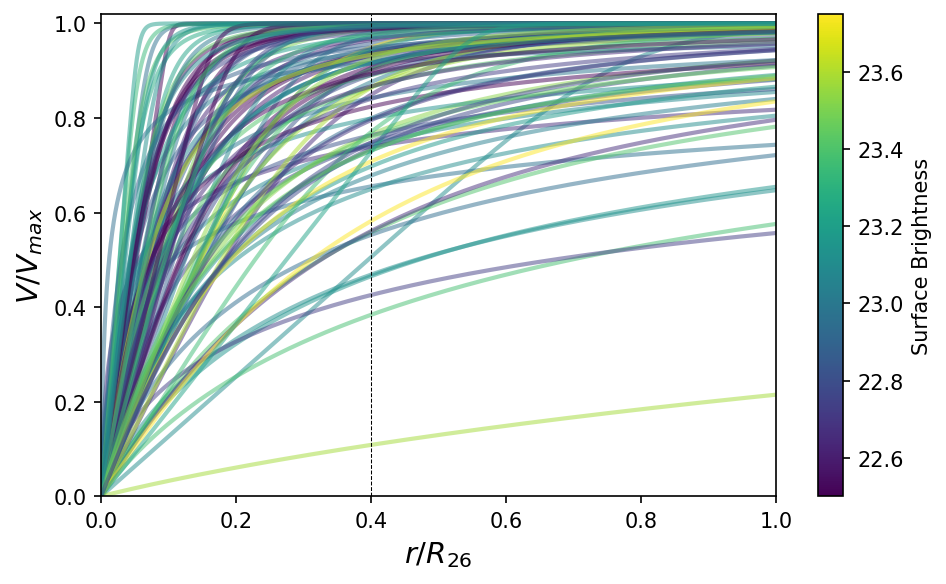

In [12]:
r = np.linspace(0, 1, 10000)

fig, ax = plt.subplots(figsize=(6.5, 4), tight_layout=True, dpi=150)

# Colormap + normalization
cmap = plt.cm.viridis
norm = mpl.colors.Normalize(vmin=22.5, vmax=23.75)

for i in range(100):
    vel = v_Vmax(SGA_manga['r_turn'][i] / SGA_manga['R26_kpc'][i],SGA_manga['alpha'][i],r)

    ax.plot(r, vel, color=cmap(norm(SGA_manga['SB'][i])), lw=2, alpha=0.5)

ax.axvline(x=0.4, color='k', lw=0.5, ls='dashed')

# Colorbar
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Surface Brightness')

ax.set_xlabel(r'$r/R_{26}$', fontsize=14)
ax.set_ylabel(r'$V/V_{max}$', fontsize=14)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)

plt.show()

## According to these curves, how many galaxies are we actually measuring $V_{\text{max}}$ for?

In [13]:
v_vmax_0p4R26 = v_Vmax((SGA_manga['r_turn']/SGA_manga['R26_kpc']), SGA_manga['alpha'], 0.4)
SGA_manga['V_0p4R26_pred'] = v_vmax_0p4R26*SGA_manga['v_max']

print(f'V/Vmax> 99% {np.sum(v_vmax_0p4R26>0.99)/len(v_vmax_0p4R26):.2f} ({np.sum(v_vmax_0p4R26>0.99)} of {len(v_vmax_0p4R26)})')
print(f'V/Vmax> 95% {np.sum(v_vmax_0p4R26>0.95)/len(v_vmax_0p4R26):.2f} ({np.sum(v_vmax_0p4R26>0.95)} of {len(v_vmax_0p4R26)})')
print(f'V/Vmax> 90% {np.sum(v_vmax_0p4R26>0.9)/len(v_vmax_0p4R26):.2f} ({np.sum(v_vmax_0p4R26>0.9)} of {len(v_vmax_0p4R26)})')

V/Vmax> 99% 0.28 (1311 of 4687)
V/Vmax> 95% 0.46 (2161 of 4687)
V/Vmax> 90% 0.59 (2770 of 4687)


# Correlations between rotation curve parameters and surface brightness

/global/u1/s/sgmoore1/DESI_SGA/TF/help_functions.py:68: RuntimeWarning: invalid value encountered in divide
  e = np.sqrt((mean2 - mean**2) / (N - 1))


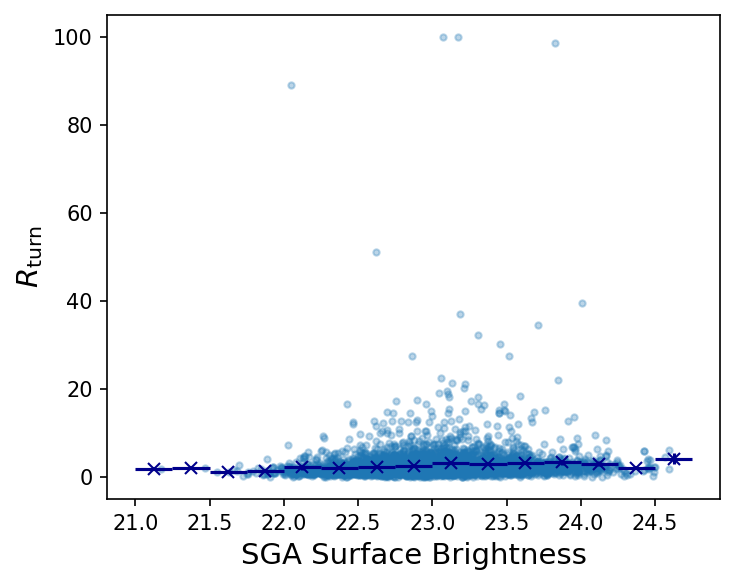

In [14]:
sbins = np.arange(21,25, 0.25)
ds = 0.5*np.diff(sbins)
sc = 0.5*(sbins[1:] + sbins[:-1])

plt.figure(figsize=(5,4), tight_layout=True, facecolor='none', dpi=150)

plt.errorbar(SGA_manga['SB'], SGA_manga['r_turn'], alpha=0.3, fmt='.')

N, y_avg, y_std = profile_histogram(
    SGA_manga['SB'],
    SGA_manga['r_turn'],
    sbins,
    weighted=False)

plt.errorbar(sc, y_avg,xerr=ds, yerr=y_std,fmt='x', color='darkblue', zorder=5)

plt.xlabel(r'SGA Surface Brightness', fontsize=14)
plt.ylabel(r'$R_{\text{turn}}$', fontsize=14)
# plt.xlim(21.5,17.5)
# plt.ylim(0,10)

plt.show();

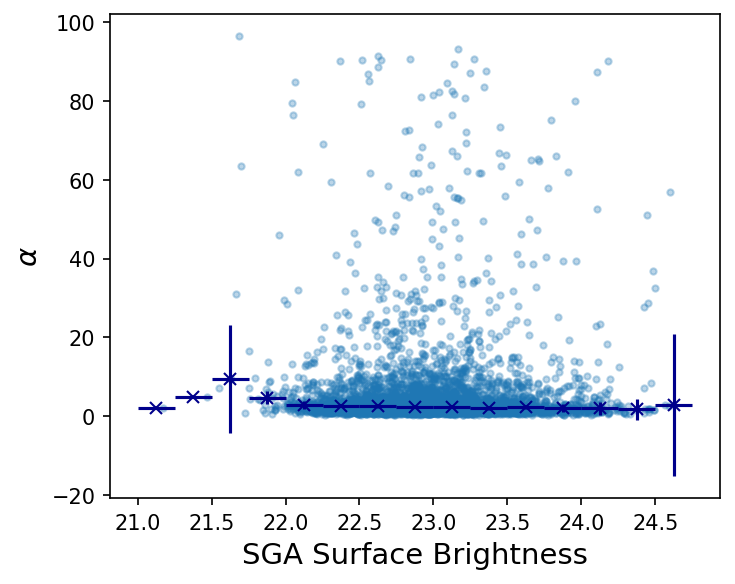

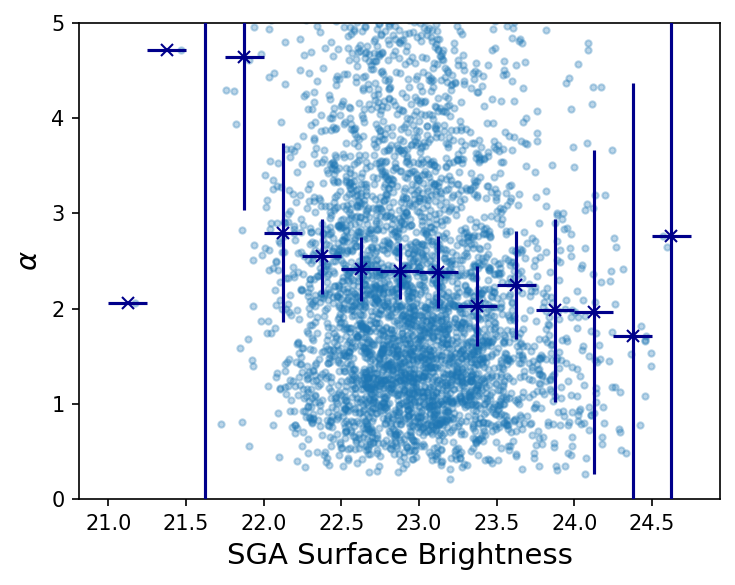

In [15]:
plt.figure(figsize=(5,4), tight_layout=True, facecolor='none', dpi=150)

plt.errorbar(SGA_manga['SB'], SGA_manga['alpha'], alpha=0.3, fmt='.')

N, y_avg, y_std = profile_histogram(
    SGA_manga['SB'],
    SGA_manga['alpha'],
    sbins,
    stat='median',)
    # weighted=False)

plt.errorbar(sc, y_avg,xerr=ds, yerr=y_std,fmt='x', color='darkblue', zorder=5)

plt.xlabel(r'SGA Surface Brightness', fontsize=14)
plt.ylabel(r'$\alpha$', fontsize=14)
# plt.xlim(21.5,17.5)
# plt.ylim(0,10)

plt.show();

plt.figure(figsize=(5,4), tight_layout=True, facecolor='none', dpi=150)

plt.errorbar(SGA_manga['SB'], SGA_manga['alpha'], alpha=0.3, fmt='.')

N, y_avg, y_std = profile_histogram(
    SGA_manga['SB'],
    SGA_manga['alpha'],
    sbins,
    stat='median',)
    # weighted=False)

plt.errorbar(sc, y_avg,xerr=ds, yerr=y_std,fmt='x', color='darkblue', zorder=5)

plt.xlabel(r'SGA Surface Brightness', fontsize=14)
plt.ylabel(r'$\alpha$', fontsize=14)
# plt.xlim(21.5,17.5)
plt.ylim(0,5)

plt.show();

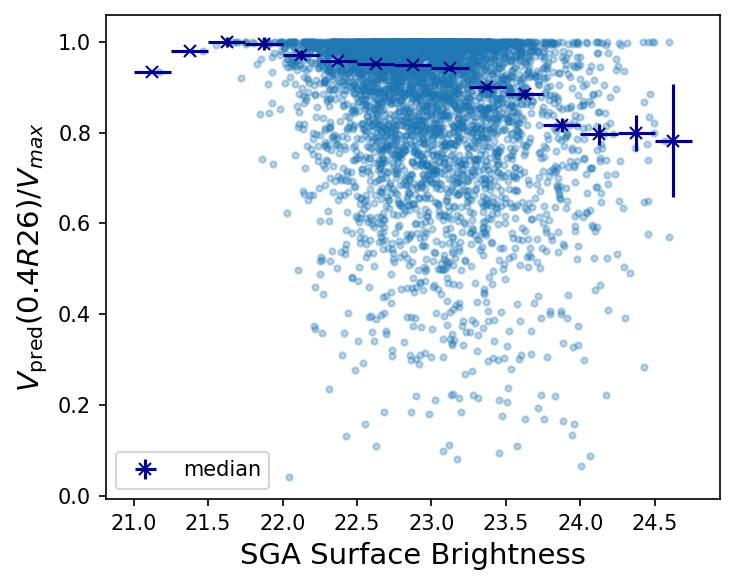

In [16]:
plt.figure(figsize=(5,4), tight_layout=True, facecolor='none', dpi=150)

plt.errorbar(SGA_manga['SB'], SGA_manga['V_0p4R26_pred']/SGA_manga['v_max'], alpha=0.3, fmt='.')

N, y_avg, y_std = profile_histogram(
    SGA_manga['SB'],
    SGA_manga['V_0p4R26_pred']/SGA_manga['v_max'],
    sbins,
    stat='median')

plt.errorbar(sc, y_avg,xerr=ds, yerr=y_std,fmt='x', color='darkblue', zorder=5, label='median')

plt.xlabel(r'SGA Surface Brightness', fontsize=14)
plt.ylabel(r'$V_{\text{pred}}(0.4R26)/V_{max}$ ', fontsize=14)
plt.legend()
# plt.xlim(21.5,17.5)
# plt.ylim(0,10)

plt.show();

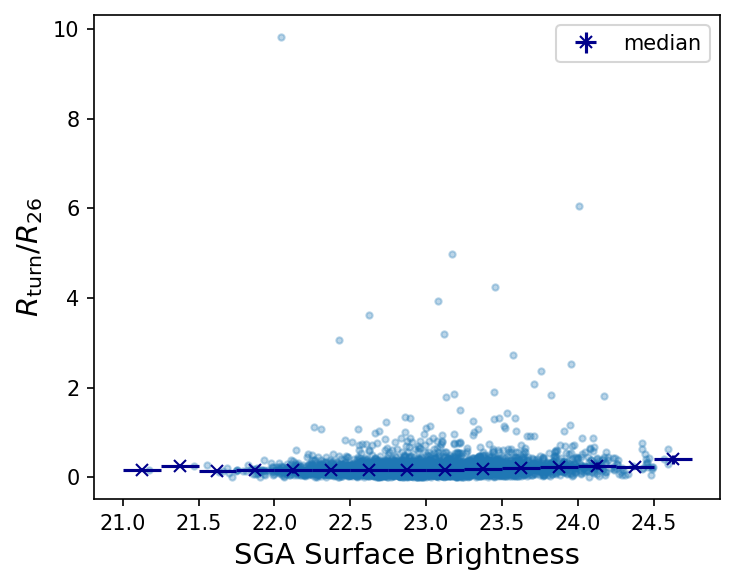

In [17]:
sbins = np.arange(21, 25, 0.25)
ds = 0.5*np.diff(sbins)
sc = 0.5*(sbins[1:] + sbins[:-1])

plt.figure(figsize=(5,4), tight_layout=True, facecolor='none', dpi=150)

plt.errorbar(SGA_manga['SB'], SGA_manga['r_turn']/SGA_manga['R26_kpc'], alpha=0.3, fmt='.')

N, y_avg, y_std = profile_histogram(
    SGA_manga['SB'],
    SGA_manga['r_turn']/SGA_manga['R26_kpc'],
    sbins,
    stat='median')

plt.errorbar(sc, y_avg,xerr=ds, yerr=y_std,fmt='x', color='darkblue', zorder=5, label='median')
plt.legend()
plt.xlabel(r'SGA Surface Brightness', fontsize=14)
plt.ylabel(r'$R_{\text{turn}}/R_{26}$', fontsize=14)
# plt.xlim(21.5,17.5)
# plt.ylim(0,10)

plt.show();

# Look at slope of rotation curves at a fixed radius

In [18]:
def rot_curve_slope(Rturn, alpha, r):
    slope = Rturn**alpha * ((Rturn**alpha + r**alpha)**(-(1+alpha)/alpha))
    return slope

In [19]:
SGA_manga['slope_0p1R26'] = rot_curve_slope((SGA_manga['r_turn']/SGA_manga['R26_kpc']), SGA_manga['alpha'], 0.1)
SGA_manga['slope_0p05R26'] = rot_curve_slope((SGA_manga['r_turn']/SGA_manga['R26_kpc']), SGA_manga['alpha'], 0.05)
SGA_manga['slope_0p2R26'] = rot_curve_slope((SGA_manga['r_turn']/SGA_manga['R26_kpc']), SGA_manga['alpha'], 0.2)
SGA_manga['slope_0p01R26'] = rot_curve_slope((SGA_manga['r_turn']/SGA_manga['R26_kpc']), SGA_manga['alpha'], 0.01)
SGA_manga['slope_0p4R26'] = rot_curve_slope((SGA_manga['r_turn']/SGA_manga['R26_kpc']), SGA_manga['alpha'], 0.4)

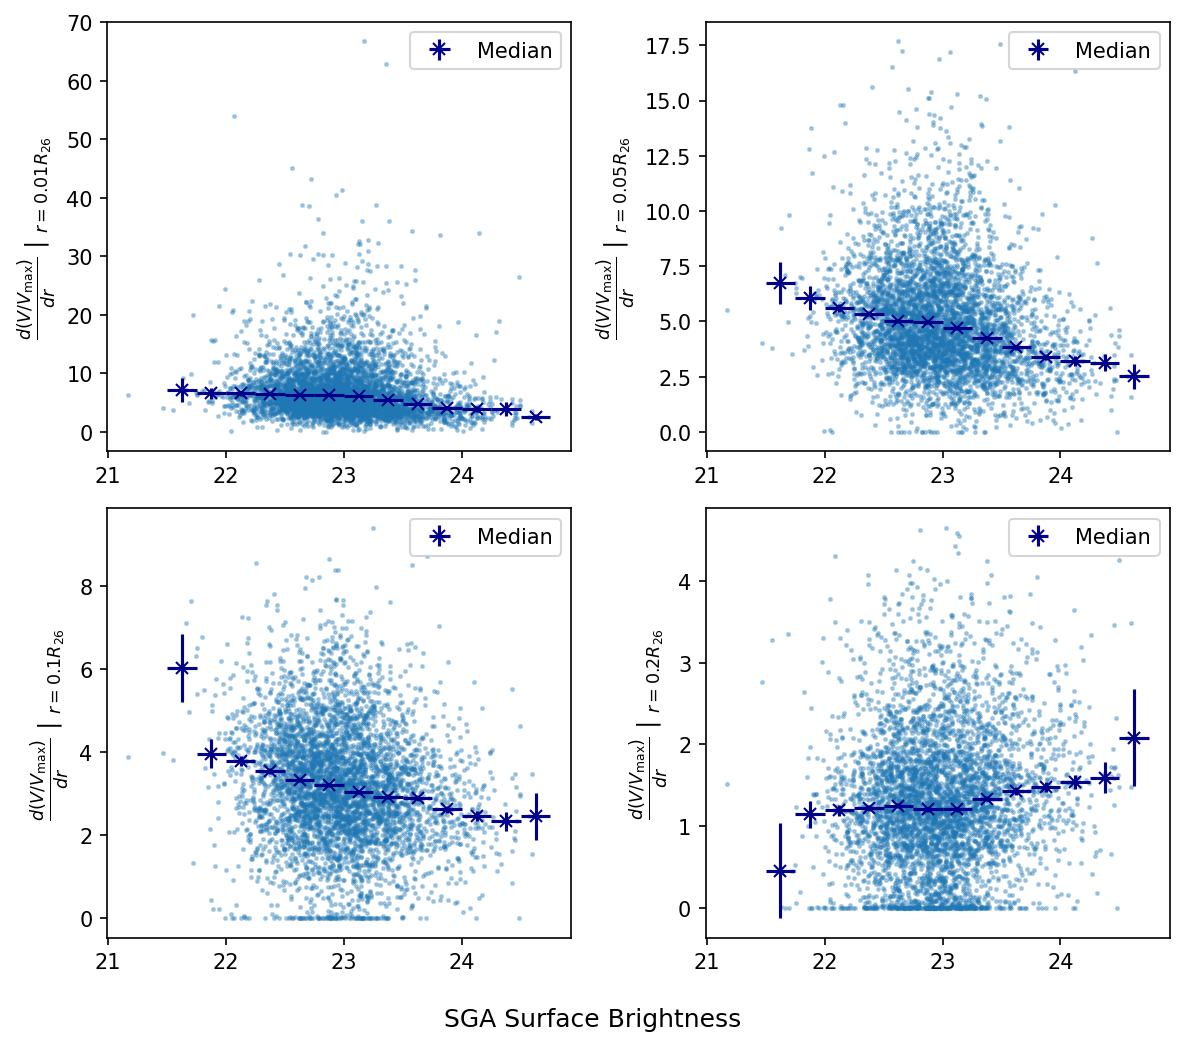

In [20]:
sbins = np.arange(21.5, 25, 0.25)
ds = 0.5 * np.diff(sbins)
sc = 0.5 * (sbins[1:] + sbins[:-1])

slope_cols = ['slope_0p01R26','slope_0p05R26','slope_0p1R26','slope_0p2R26']
radii = ['0.01', '0.05', '0.1', '0.2']

fig, axes = plt.subplots(
    2, 2,
    figsize=(8, 7),
    tight_layout=True,
    facecolor='none',
    dpi=150
)

for ax, slope_col, radius in zip(axes.flat, slope_cols, radii):

    ax.errorbar(SGA_manga['SB'], SGA_manga[slope_col], alpha=0.3, fmt='.', ms=3)

    N, y_avg, y_std = profile_histogram(SGA_manga['SB'],
                                        SGA_manga[slope_col],
                                        sbins,
                                        stat='median')

    ax.errorbar(sc, y_avg, xerr=ds, yerr=y_std, fmt='x', color='darkblue', zorder=5, label='Median')
    ax.legend()
    ax.set_ylabel(r'$\frac{d (V/V_{\mathrm{max}})}{dr}' r'\mid_{r=' + radius + r'R_{26}}$',fontsize=12)

fig.supxlabel('SGA Surface Brightness', fontsize=12)
plt.show()

# What about surface brightness within $R_{90}$?

The magnitude at $R_{90}$ can be computed based on the SGA curve of growth parameters, and we will use the value of $R_{90}$ provided from the MaNGA fits.

In [21]:
SGA_manga['SGA_R90'] = 10 * (SGA_manga['R_COG_PARAMS_ALPHA1']**-1 * (np.exp( -np.log10(0.9)/(0.4*SGA_manga['R_COG_PARAMS_M0']))-1))**(-1/SGA_manga['R_COG_PARAMS_ALPHA2'])
SGA_manga['R90_MAG'] = SGA_manga['R_COG_PARAMS_MTOT'] + SGA_manga['R_COG_PARAMS_M0']*np.log(1+SGA_manga['R_COG_PARAMS_ALPHA1']*(SGA_manga['SGA_R90']/10)**(-SGA_manga['R_COG_PARAMS_ALPHA2']))

SGA_manga['SB_R90'] = SGA_manga['R90_MAG'] + 2.5*np.log10(np.pi*SGA_manga['SGA_R90']**2*SGA_manga['BA'])

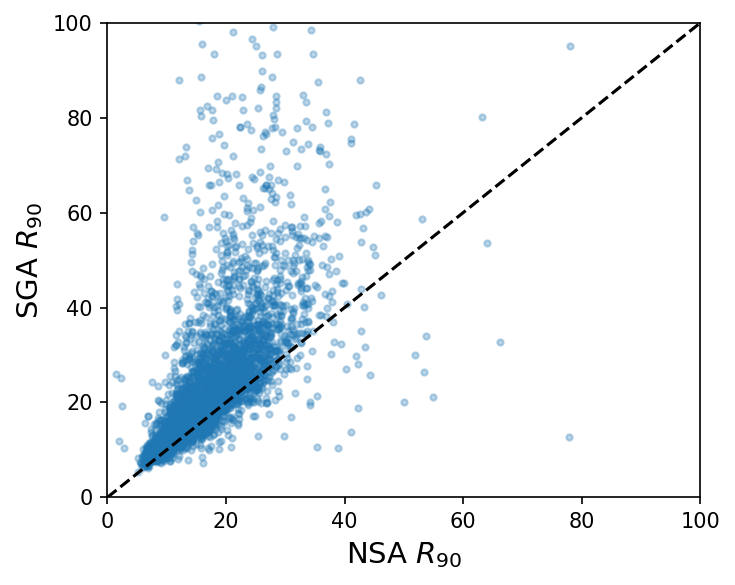

In [22]:
plt.figure(figsize=(5,4), tight_layout=True, facecolor='none', dpi=150)

plt.errorbar(SGA_manga['nsa_elpetro_th90'], SGA_manga['SGA_R90'], alpha=0.3, fmt='.')

plt.plot((0,100), (0,100), 'k--', zorder=10)

plt.xlabel(r'NSA $R_{90}$', fontsize=14)
plt.ylabel(r'SGA $R_{90}$', fontsize=14)

plt.ylim(0,100)
plt.xlim(0,100)

plt.show();

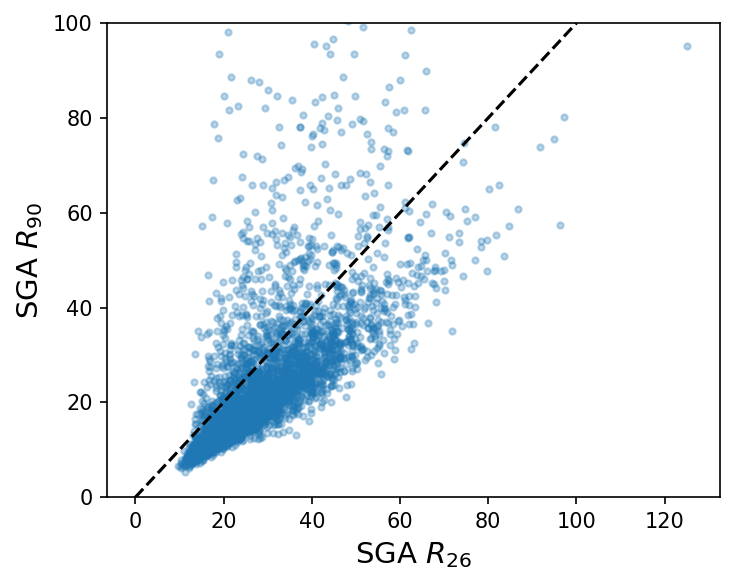

In [23]:
# sbins = np.arange(16,22, 0.5)
# ds = 0.5*np.diff(sbins)
# sc = 0.5*(sbins[1:] + sbins[:-1])

plt.figure(figsize=(5,4), tight_layout=True, facecolor='none', dpi=150)

plt.errorbar(SGA_manga['SMA_SB26'], SGA_manga['SGA_R90'], alpha=0.3, fmt='.')

plt.plot((0,100), (0,100), 'k--', zorder=10)

plt.xlabel(r'SGA $R_{26}$', fontsize=14)
plt.ylabel(r'SGA $R_{90}$', fontsize=14)

plt.ylim(0,100)

plt.show();

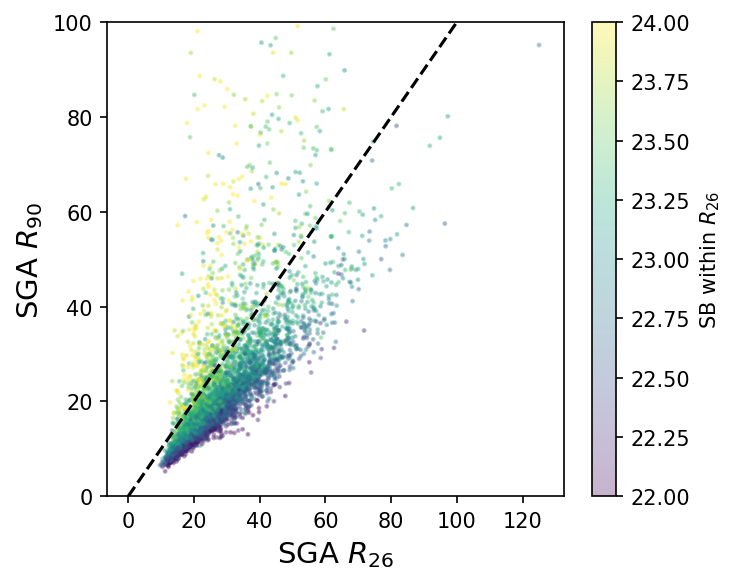

In [24]:
# sbins = np.arange(16,22, 0.5)
# ds = 0.5*np.diff(sbins)
# sc = 0.5*(sbins[1:] + sbins[:-1])

plt.figure(figsize=(5,4), tight_layout=True, facecolor='none', dpi=150)

plt.scatter(SGA_manga['SMA_SB26'], SGA_manga['SGA_R90'], alpha=0.3, s=2, c=SGA_manga['SB'], vmin=22, vmax=24)

plt.plot((0,100), (0,100), 'k--')
plt.colorbar(label=R'SB within $R_{26}$')
plt.xlabel(r'SGA $R_{26}$', fontsize=14)
plt.ylabel(r'SGA $R_{90}$', fontsize=14)

plt.ylim(0,100)

plt.show();

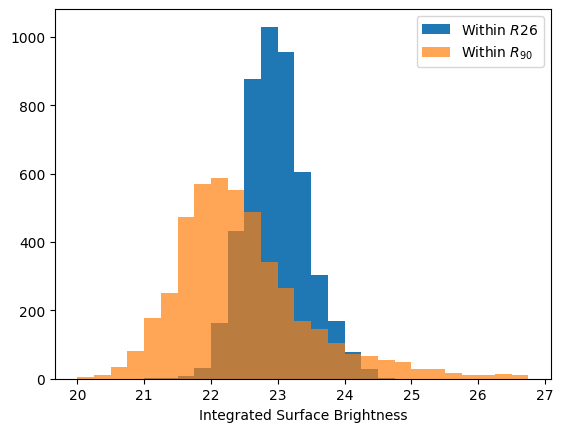

In [25]:
plt.hist(SGA_manga['SB'], bins=np.arange(20,27,0.25), label=r'Within $R26$')
plt.hist(SGA_manga['SB_R90'], bins=np.arange(20,27,0.25), label=r'Within $R_{90}$', alpha=0.7)
plt.xlabel('Integrated Surface Brightness')

plt.legend()

## Look at if the rotation curve parameter trends are more apparent here

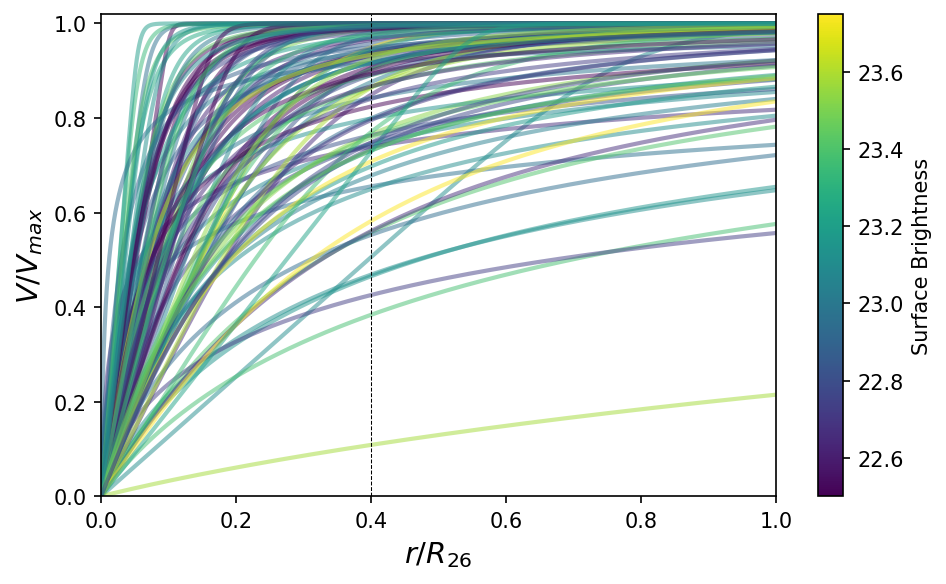

In [26]:
r = np.linspace(0, 1, 10000)

fig, ax = plt.subplots(figsize=(6.5, 4), tight_layout=True, dpi=150)

for i in range(100):
    vel = v_Vmax(SGA_manga['r_turn'][i] / SGA_manga['R26_kpc'][i],SGA_manga['alpha'][i],r)
    ax.plot(r, vel, color=cmap(norm(SGA_manga['SB'][i])), lw=2, alpha=0.5)

ax.axvline(x=0.4, color='k', lw=0.5, ls='dashed')

# Colorbar
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Surface Brightness')

ax.set_xlabel(r'$r/R_{26}$', fontsize=14)
ax.set_ylabel(r'$V/V_{max}$', fontsize=14)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)

plt.show();

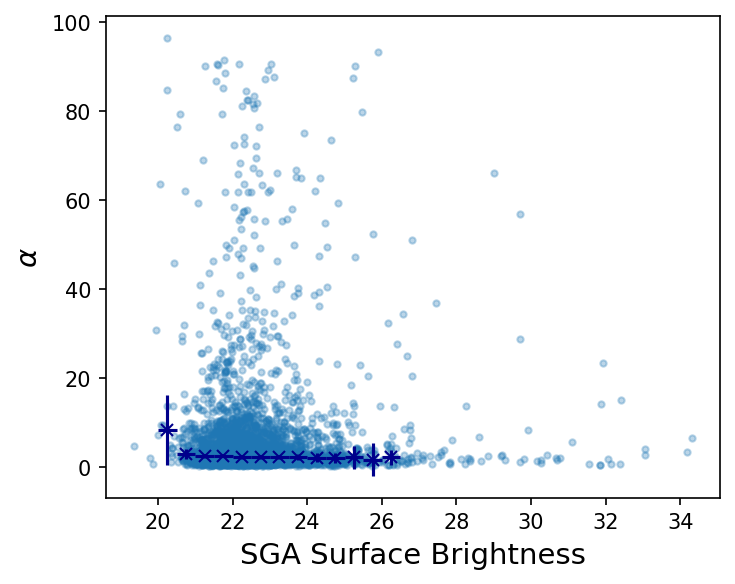

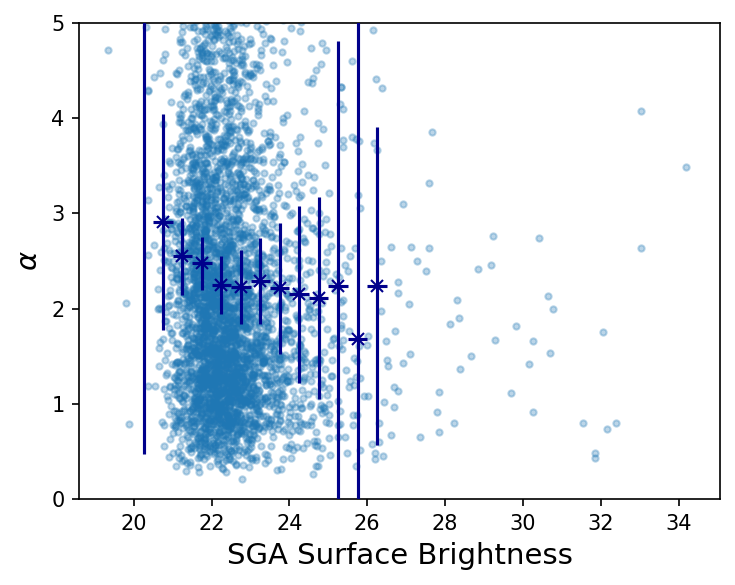

In [27]:
sbins = np.arange(20, 27, 0.5)
ds = 0.5 * np.diff(sbins)
sc = 0.5 * (sbins[1:] + sbins[:-1])

plt.figure(figsize=(5,4), tight_layout=True, facecolor='none', dpi=150)

plt.errorbar(SGA_manga['SB_R90'], SGA_manga['alpha'], alpha=0.3, fmt='.')

N, y_avg, y_std = profile_histogram(
    SGA_manga['SB_R90'],
    SGA_manga['alpha'],
    sbins,
    stat='median',)
    # weighted=False)

plt.errorbar(sc, y_avg,xerr=ds, yerr=y_std,fmt='x', color='darkblue', zorder=5)

plt.xlabel(r'SGA Surface Brightness', fontsize=14)
plt.ylabel(r'$\alpha$', fontsize=14)
# plt.xlim(21.5,17.5)
# plt.ylim(0,10)

plt.show();

plt.figure(figsize=(5,4), tight_layout=True, facecolor='none', dpi=150)

plt.errorbar(SGA_manga['SB_R90'], SGA_manga['alpha'], alpha=0.3, fmt='.')

N, y_avg, y_std = profile_histogram(
    SGA_manga['SB_R90'],
    SGA_manga['alpha'],
    sbins,
    stat='median',)
    # weighted=False)

plt.errorbar(sc, y_avg,xerr=ds, yerr=y_std,fmt='x', color='darkblue', zorder=5)

plt.xlabel(r'SGA Surface Brightness', fontsize=14)
plt.ylabel(r'$\alpha$', fontsize=14)
# plt.xlim(21.5,17.5)
plt.ylim(0,5)

plt.show();

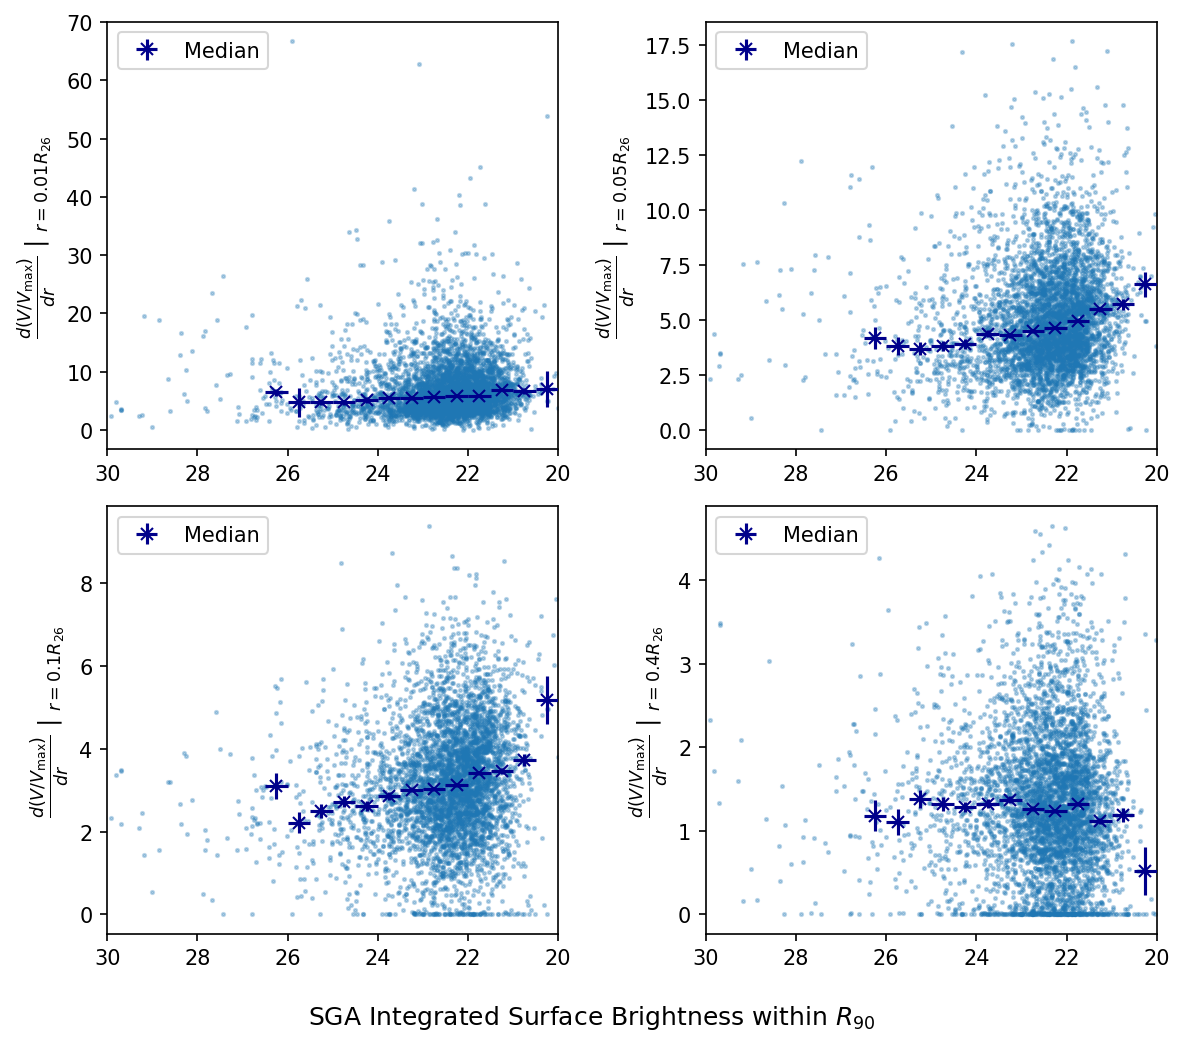

In [28]:
slope_cols = ['slope_0p01R26','slope_0p05R26','slope_0p1R26','slope_0p2R26']
radii = ['0.01', '0.05', '0.1', '0.4']

fig, axes = plt.subplots(
    2, 2,
    figsize=(8, 7),
    tight_layout=True,
    facecolor='none',
    dpi=150
)

for ax, slope_col, radius in zip(axes.flat, slope_cols, radii):

    ax.errorbar(SGA_manga['SB_R90'], SGA_manga[slope_col], alpha=0.3, fmt='.', ms=3)

    N, y_avg, y_std = profile_histogram(SGA_manga['SB_R90'],
                                        SGA_manga[slope_col],
                                        sbins,
                                        stat='median')

    ax.errorbar(sc, y_avg, xerr=ds, yerr=y_std, fmt='x', color='darkblue', zorder=5, label='Median')
    ax.legend()
    ax.set_xlim(30,20)
    ax.set_ylabel(r'$\frac{d (V/V_{\mathrm{max}})}{dr}' r'\mid_{r=' + radius + r'R_{26}}$',fontsize=12)

fig.supxlabel(r'SGA Integrated Surface Brightness within $R_{90}$ ', fontsize=12)
plt.show()

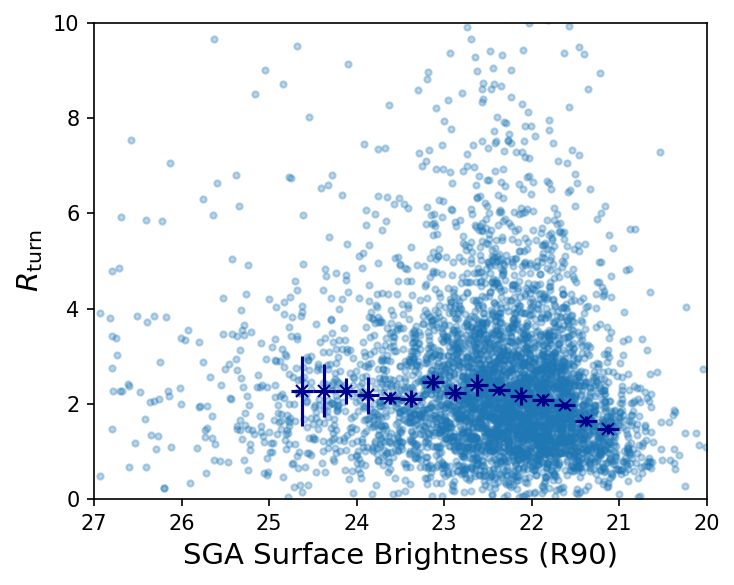

In [29]:
sbins = np.arange(21,25, 0.25)
ds = 0.5*np.diff(sbins)
sc = 0.5*(sbins[1:] + sbins[:-1])

plt.figure(figsize=(5,4), tight_layout=True, facecolor='none', dpi=150)

plt.errorbar(SGA_manga['SB_R90'], SGA_manga['r_turn'], alpha=0.3, fmt='.')

N, y_avg, y_std = profile_histogram(
    SGA_manga['SB_R90'],
    SGA_manga['r_turn'],
    sbins,
    stat='median')

plt.errorbar(sc, y_avg,xerr=ds, yerr=y_std,fmt='x', color='darkblue', zorder=5)

plt.xlabel(r'SGA Surface Brightness (R90)', fontsize=14)
plt.ylabel(r'$R_{\text{turn}}$', fontsize=14)
plt.xlim(27,20)
plt.ylim(0,10)

plt.show();

# Calculate the radius such that $V/V_{\text{max}} = k$

For now, we will use k=0.95

In [30]:
def r_vmax_frac(Rturn, alpha, factor):
    r = ((factor**alpha* Rturn**alpha)/(1-factor**alpha)**(1/alpha))
    return r

In [31]:
SGA_manga['r_0p95vmax'] = r_vmax_frac((SGA_manga['r_turn']/SGA_manga['R26_kpc']), SGA_manga['alpha'], 0.95)
SGA_manga['r_0p99vmax'] = r_vmax_frac((SGA_manga['r_turn']/SGA_manga['R26_kpc']), SGA_manga['alpha'], 0.99)

In [32]:
sga_manga_smooth = SGA_manga[SGA_manga['alpha']< 10]

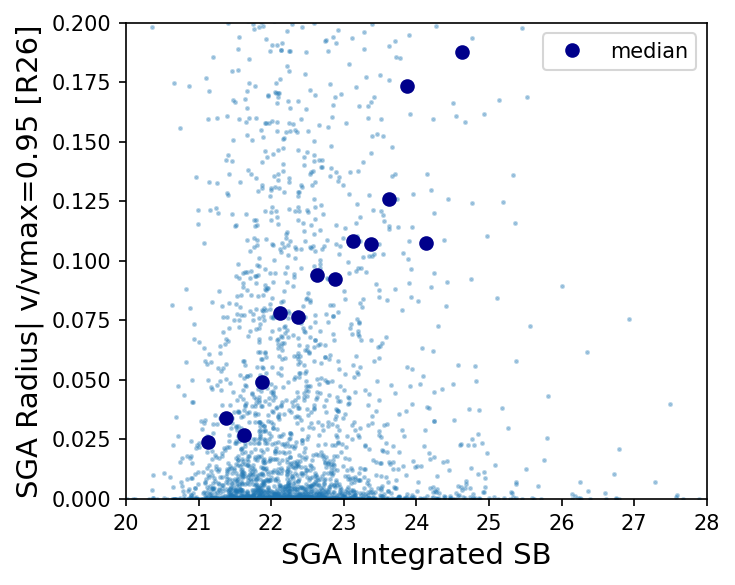

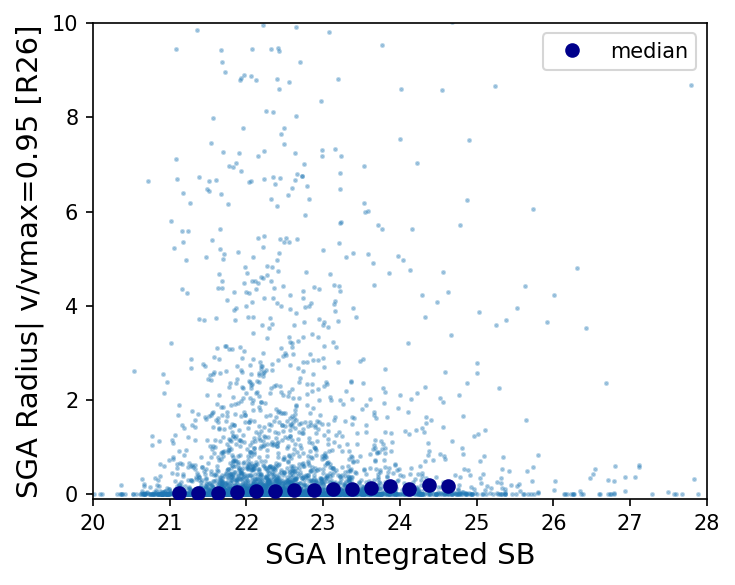

In [38]:
sbins = np.arange(21,25, 0.25)
ds = 0.5*np.diff(sbins)
sc = 0.5*(sbins[1:] + sbins[:-1])
plt.figure(figsize=(5,4), tight_layout=True, facecolor='none', dpi=150)

plt.scatter(sga_manga_smooth['SB_R90'], sga_manga_smooth['r_0p95vmax'], alpha=0.3, s=2)

N, y_avg, y_std = profile_histogram(
    sga_manga_smooth['SB_R90'],
    sga_manga_smooth['r_0p95vmax'],
    sbins,
    stat='median')

plt.errorbar(sc, y_avg, fmt='o', color='darkblue', zorder=5, label='median')
plt.legend()
plt.xlabel(r'SGA Integrated SB', fontsize=14)
plt.ylabel(r'SGA Radius| v/vmax=0.95 [R26]', fontsize=14)
plt.xlim(20,28)
plt.ylim(-0.0001,0.2)

plt.show();

sbins = np.arange(21,25, 0.25)
ds = 0.5*np.diff(sbins)
sc = 0.5*(sbins[1:] + sbins[:-1])
plt.figure(figsize=(5,4), tight_layout=True, facecolor='none', dpi=150)

plt.scatter(sga_manga_smooth['SB_R90'], sga_manga_smooth['r_0p95vmax'], alpha=0.3, s=2)

N, y_avg, y_std = profile_histogram(
    sga_manga_smooth['SB_R90'],
    sga_manga_smooth['r_0p95vmax'],
    sbins,
    stat='median')

plt.errorbar(sc, y_avg, fmt='o', color='darkblue', zorder=5, label='median')
plt.legend()
plt.xlabel(r'SGA Integrated SB', fontsize=14)
plt.ylabel(r'SGA Radius| v/vmax=0.95 [R26]', fontsize=14)
plt.xlim(20,28)
plt.ylim(-0.1,10)

plt.show();

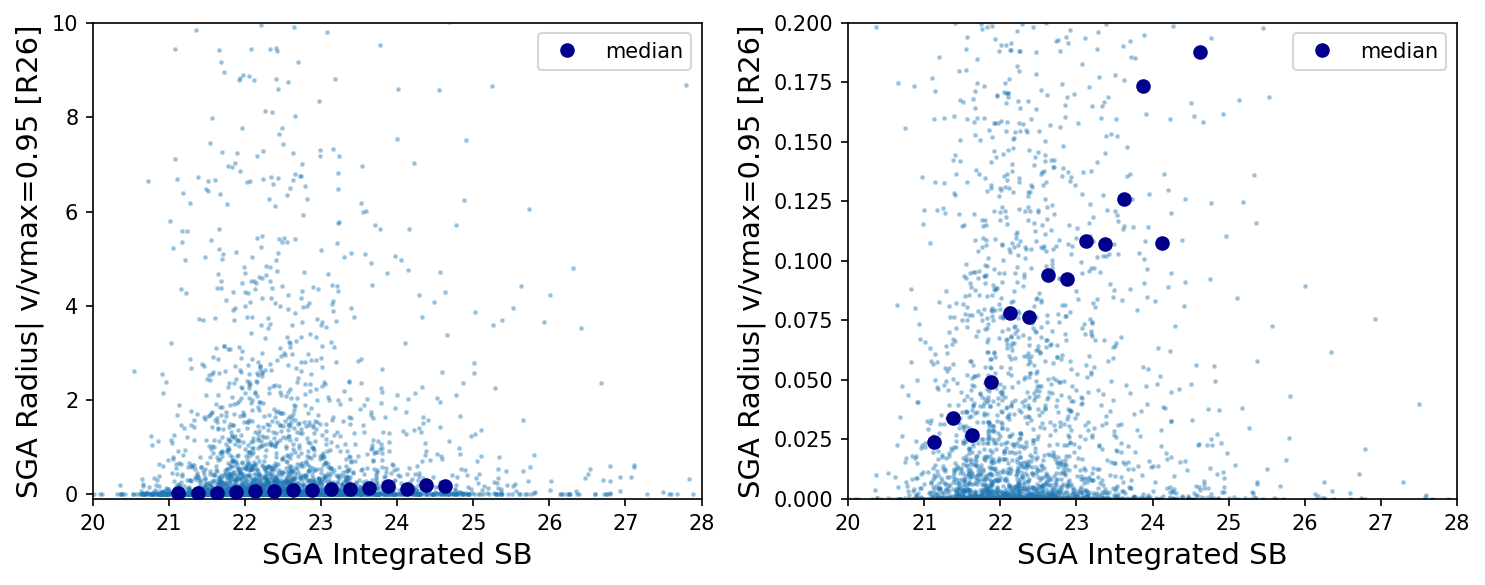

In [40]:
sbins = np.arange(21,25, 0.25)
ds = 0.5*np.diff(sbins)
sc = 0.5*(sbins[1:] + sbins[:-1])
plt.figure(figsize=(10,4), tight_layout=True, facecolor='none', dpi=150)

plt.subplot(1,2,2)
plt.scatter(sga_manga_smooth['SB_R90'], sga_manga_smooth['r_0p95vmax'], alpha=0.3, s=2)

N, y_avg, y_std = profile_histogram(
    sga_manga_smooth['SB_R90'],
    sga_manga_smooth['r_0p95vmax'],
    sbins,
    stat='median')

plt.errorbar(sc, y_avg, fmt='o', color='darkblue', zorder=5, label='median')
plt.legend()
plt.xlabel(r'SGA Integrated SB', fontsize=14)
plt.ylabel(r'SGA Radius| v/vmax=0.95 [R26]', fontsize=14)
plt.xlim(20,28)
plt.ylim(-0.0001,0.2)

plt.subplot(1,2,1)
plt.scatter(sga_manga_smooth['SB_R90'], sga_manga_smooth['r_0p95vmax'], alpha=0.3, s=2)

N, y_avg, y_std = profile_histogram(
    sga_manga_smooth['SB_R90'],
    sga_manga_smooth['r_0p95vmax'],
    sbins,
    stat='median')

plt.errorbar(sc, y_avg, fmt='o', color='darkblue', zorder=5, label='median')
plt.legend()
plt.xlabel(r'SGA Integrated SB', fontsize=14)
plt.ylabel(r'SGA Radius| v/vmax=0.95 [R26]', fontsize=14)
plt.xlim(20,28)
plt.ylim(-0.1,10)

plt.show();

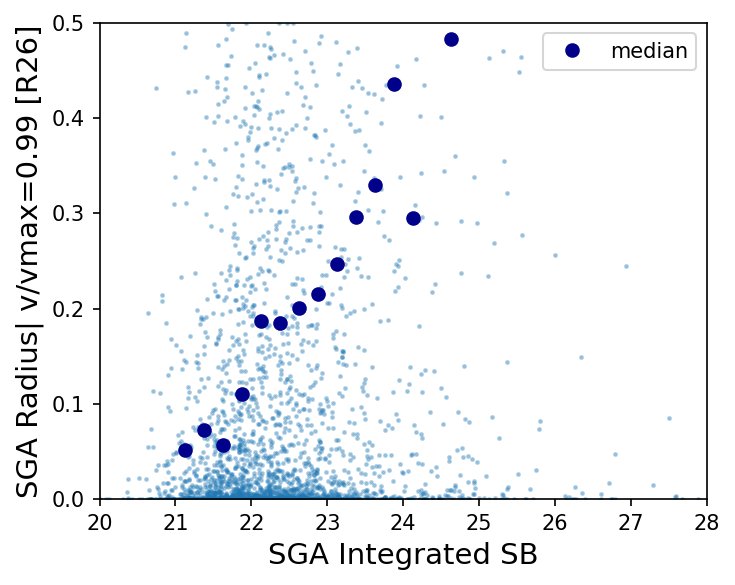

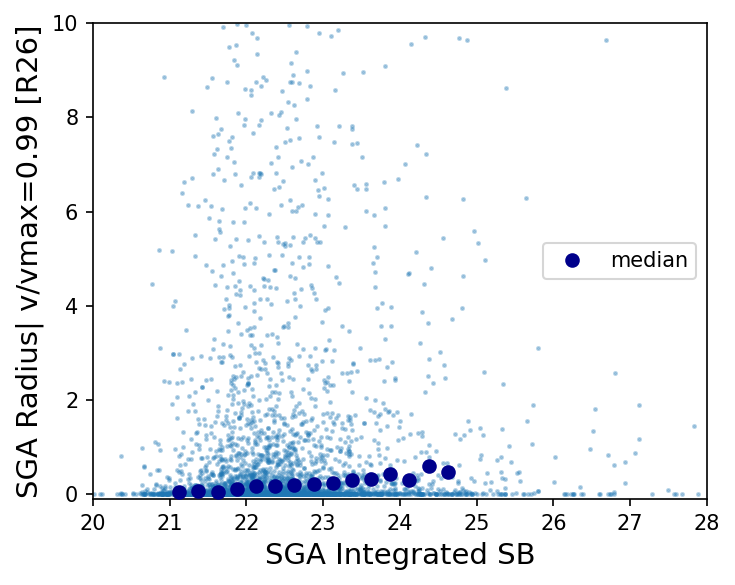

In [37]:
sbins = np.arange(21,25, 0.25)
ds = 0.5*np.diff(sbins)
sc = 0.5*(sbins[1:] + sbins[:-1])
plt.figure(figsize=(5,4), tight_layout=True, facecolor='none', dpi=150)

plt.scatter(sga_manga_smooth['SB_R90'], sga_manga_smooth['r_0p99vmax'], alpha=0.3, s=2)

N, y_avg, y_std = profile_histogram(
    sga_manga_smooth['SB_R90'],
    sga_manga_smooth['r_0p99vmax'],
    sbins,
    stat='median')

plt.errorbar(sc, y_avg, fmt='o', color='darkblue', zorder=5, label='median')
plt.legend()
plt.xlabel(r'SGA Integrated SB', fontsize=14)
plt.ylabel(r'SGA Radius| v/vmax=0.99 [R26]', fontsize=14)
plt.xlim(20,28)
plt.ylim(-0.0001,0.5)

plt.show();

sbins = np.arange(21,25, 0.25)
ds = 0.5*np.diff(sbins)
sc = 0.5*(sbins[1:] + sbins[:-1])
plt.figure(figsize=(5,4), tight_layout=True, facecolor='none', dpi=150)

plt.scatter(sga_manga_smooth['SB_R90'], sga_manga_smooth['r_0p99vmax'], alpha=0.3, s=2)

N, y_avg, y_std = profile_histogram(
    sga_manga_smooth['SB_R90'],
    sga_manga_smooth['r_0p99vmax'],
    sbins,
    stat='median')

plt.errorbar(sc, y_avg, fmt='o', color='darkblue', zorder=5, label='median')
plt.legend()
plt.xlabel(r'SGA Integrated SB', fontsize=14)
plt.ylabel(r'SGA Radius| v/vmax=0.99 [R26]', fontsize=14)
plt.xlim(20,28)
plt.ylim(-0.1,10)

plt.show();

In [130]:
SGA_manga.write('/pscratch/sd/s/sgmoore1/TF/sga_manga_rotcurve_comparisons.fits')
# !chgrp desi /pscratch/sd/s/sgmoore1/TF/sga_manga_rotcurve_comparisons.fits